In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import copy
import platform
import subprocess
import json
from io import StringIO
import numpy as np
import pandas as pd
import networkx as nx
from networkx.readwrite import json_graph
from pathlib import Path


from html_from_assignments import NMRProblem
import jsonUtils

import nmrsolution
# from globals import svgDimensions

from globals import SVG_DIMENSIONS as svgDimensions
from simulatedAnnealing_v5 import SimulatedAnnealing2

import rdkit
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.Chem import Draw

In [3]:
%matplotlib inline

In [4]:
platform.system()

'Darwin'

In [5]:
if platform.system() == "Darwin":

    fn_json = Path("/Users/vsmw51/Downloads/4Eric/caryophyllene/caryophyllene_assignments_mresnova.json")
    fn_json = Path("/Users/vsmw51/Downloads/4Eric/caryophyllene/caryophyllene_assignments_mresnova.json")
    fn_json = Path("/Users/vsmw51/OneDrive - Durham University/projects/programming/2025/python/awh/bruker_data_sets/E72507_04164043_propyl_benzoate/04164043/04164043_assignments.json")
    fn_json = Path("/opt/topspin4.5.0/examdata/exam_CMCse_1/exam_CMCse_1_assignments.json")
    fn_json = Path("/Users/vsmw51/Dropbox/4Eric/Cytochalasin-B3/Cytochalasin-B_assignments_mresnova.json")
    fn_json = Path("/Users/vsmw51/Dropbox/4Eric/Cytochalasin-B-kate/Cytochalasin-B-kate_assignments_mresnova.json")
    fn_json = Path("/Users/vsmw51/Dropbox/4Eric/NMS_vsmw51_10092432_E72604_ethylbenzene/NMS_vsmw51_10092432_E72604_ethylbenzene_assignments_mresnova.json")


elif platform.system() == "Windows":
    fn_json = Path(r"C:\Users\vsmw51\OneDrive - Durham University\projects\programming\2025\python\awh\bruker_data_sets\E72507_04164043_propyl_benzoate\04164043\04164043_jeol_inputdata.json")
    

In [6]:
with open(fn_json, 'r') as f:
    json_data = json.load(f)

In [7]:
problemdata_json = NMRProblem.from_mnova_dict(json_data)


from_mnova_dict(cls,json_data: dict):

Processing key: smiles
	data[smiles].keys()
 dict_keys(['datatype', 'count', 'data']) 

v.items():
 dict_items([('datatype', 'smiles'), ('count', 1), ('data', {'0': 'CCc1ccccc1'})]) 

Processing key: molfile
	data[molfile].keys()
 dict_keys(['datatype', 'count', 'data']) 

v.items():
 dict_items([('datatype', 'molfile'), ('count', 1), ('data', {'0': '\r\n  Mnova   04102612322D\r\n\r\n  8  8  0  0  0  0  0  0  0  0999 V2000\r\n    0.0000    0.0000    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0\r\n    1.3337   -0.7700    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0\r\n    1.3337   -2.3100    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0\r\n    0.0000   -3.0800    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0\r\n   -1.3337   -2.3100    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0\r\n   -1.3337   -0.7700    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0\r\n    0.0502    1.5392    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0\r\n   -0.9343    2.723

In [8]:
solution = nmrsolution.NMRsolution(problemdata_json)

self.expts_available {'SKIP', 'DDEPTCH3ONLY', 'HSQC_CLIPCOSY', 'HMBC', 'HSQC'}
problemdata_json.dataframes.keys() dict_keys(['smiles', 'molfile', 'allAtomsInfo', 'carbonAtomsInfo', 'nmrAssignments', 'c13predictions', 'chosenSpectra', 'MNOVAcalcMethod', 'workingDirectory', 'workingFilename', 'simulatedAnnealing', 'spectraWithPeaks', 'molecule', 'HSQC', 'HMBC', 'DDEPTCH3ONLY', 'HSQC_CLIPCOSY', 'H1_1D', 'C13_1D', 'DEPT135', 'H1_pureshift', 'COSY', 'NOESY'])
Prediction from NMRSHIFTDB2
Prediction from NMRSHIFTDB2
BEFORE ::: self.molprops_df
    idx  atom_idx  implicitHs  totalNumHs  degree  hybridization  aromatic
0    0         0           0           0       3              3      True
1    1         1           1           1       2              3      True
2    2         2           1           1       2              3      True
3    3         3           1           1       2              3      True
4    4         4           1           1       2              3      True
5    5      

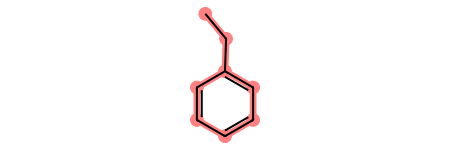

In [9]:
solution.expected_molecule

In [10]:
solution.nmrsolution_failed

False

In [11]:
solution.expected_molecule.nmrshiftdb_failed

False

In [12]:
solution.expected_molecule.molprops_df[["ppm"]]

,ppm
idx,
0,144.00
1,127.77
2,128.30
3,125.63
4,128.30
5,127.77
6,29.34
7,15.74


In [13]:
ok, msg = solution.init_class_from_json()
ok,msg

self.HSQC_data_present: True
self.hsqc_df:
      f2_ppm      f1_ppm    intensity  signaltype Annotation
1  7.404536  128.409278  5335.453049           0           
2  7.323511  127.954800  5976.962592           0           
3  7.297984  125.690985  2853.151293           0           
4  2.775908   28.995545 -3983.825282           0           
5  1.370347   15.718719  5301.328632           0           
p0 28.995544901812533 <class 'float'>
init_c13_from_hsqc_and_hmbc
init_pureshift_from_h1
self.C13indexC13ppm {1: 144.33424746450788, 2: 128.40927804252107, 3: 127.95479972630244, 4: 125.69098496156238, 5: 28.995544901812533}
1
2
3
4
5
self.hsqc after adding index columns
      f2_ppm      f1_ppm    intensity  signaltype Annotation  f1_i  f2_i  \
1  7.404536  128.409278  5335.453049           0                2     1   
2  7.323511  127.954800  5976.962592           0                3     2   
3  7.297984  125.690985  2853.151293           0                4     3   
4  2.775908   28.995545

/Users/vsmw51/Library/CloudStorage/OneDrive-DurhamUniversity/projects/programming/2025/python/awh/simpleNMRtools2/nmrsolution.py:1461: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '79.78845608028654' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[idx, f"{column_name}_prob"] = stats.norm.pdf(
/Users/vsmw51/Library/CloudStorage/OneDrive-DurhamUniversity/projects/programming/2025/python/awh/simpleNMRtools2/nmrsolution.py:1461: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '159.57691216057307' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[idx, f"{column_name}_prob"] = stats.norm.pdf(
/Users/vsmw51/Library/CloudStorage/OneDrive-DurhamUniversity/projects/programming/2025/python/awh/simpleNMRtools2/nmrsolution.py:1461: FutureWarning:

(True, 'ok')

In [14]:
rtn_msg, rtn_num = solution.assign_CH3_CH2_CH1_overall()
rtn_msg, rtn_num

assign_CH3_CH2_CH1_in_HSQC_using_Assignments
c13_from_hsqc and H1_data_missing
CH1_mol_df.shape[0]: 5
num_CH3CH1_hsqc: 4
CH3CH1_hsqc_df.shape[0]: 4
CH3CH1_mol_df.shape[0]: 6
CH3CH1_sym_mol_df.shape[0]: 4
CH3 groups already assigned
ok 200


('ok', 200)

In [15]:
solution.assign_CH3_CH2_CH1_in_HSQC_using_Assignments()

assign_CH3_CH2_CH1_in_HSQC_using_Assignments


In [16]:
solution.assign_CH3_CH1_in_HSQC_using_H1()

In [17]:
solution.assign_CH3_CH1_in_HSQC_using_expected_molecule()

c13_from_hsqc and H1_data_missing
CH1_mol_df.shape[0]: 5
num_CH3CH1_hsqc: 4
CH3CH1_hsqc_df.shape[0]: 4
CH3CH1_mol_df.shape[0]: 6
CH3CH1_sym_mol_df.shape[0]: 4
CH3 groups already assigned


In [18]:
solution.transfer_hsqc_info_to_c13()
solution.transfer_hsqc_info_to_h1()

In [19]:
solution.initialise_prior_to_carbon_assignment()

('ok', 200)

In [20]:
rtn_msg, rtn_num = solution.attempt_assignment_CH3_CH2_CH1_to_C13_table()
rtn_msg, rtn_num

('ok', 200)

In [21]:
solution.update_assignments_expt_dataframes()

In [22]:
G2 = nmrsolution.create_network_graph(solution.c13, solution.h1)
G2 = nmrsolution.add_all_cosy_edges_to_graph(
    G2, solution.cosy, solution.hsqc_clipcosy, solution.h1
)
G2 = nmrsolution.add_all_hmbc_edges_to_graph(
    G2, solution.hmbc, solution.h1, solution.c13
)

Adding HMBC edges 1


In [23]:
jsonGraphData = json_graph.node_link_data(G2) # reverted back to original as edges="links" was causing problems
jsonGraphData["moved_nodes"] = jsonGraphData["nodes"]
solution.initiate_molgraph( json_data, G2)

#  convert the molgraph to a json object
jsonGraphData_mol = json_graph.node_link_data(solution.molgraph) # reverted back to original as edges="links" was causing problems

# calculate the shortest paths between all pairs of nodes in the molgraph
shortest_paths = dict(nx.all_pairs_dijkstra_path_length(solution.molgraph))

/Users/vsmw51/opt/anaconda3/envs/py313/lib/python3.13/site-packages/networkx/readwrite/json_graph/node_link.py:142: FutureWarning: 
The default value will be `edges="edges" in NetworkX 3.6.

To make this warning go away, explicitly set the edges kwarg, e.g.:

  nx.node_link_data(G, edges="links") to preserve current behavior, or
  nx.node_link_data(G, edges="edges") for forward compatibility.
  warnings.warn(


In [24]:
svgWidth = svgDimensions.svg_width
svgHeight = svgDimensions.svg_height
molWidth = svgDimensions.mol_width
molHeight = svgDimensions.mol_height

catoms_df = solution.expected_molecule.molprops_df[
    [
        "ppm",
        "atom_idx",
        "atomNumber",
        "numProtons",
        "x",
        "y",
        'sym_atom_idx',
        'sym_atomNumber',
    ]
].copy()

# rename ppm to ppm_calculated
catoms_df.rename(columns={"ppm": "ppm_calculated"}, inplace=True)
# renam atom_idx to id
catoms_df.rename(columns={"atom_idx": "id"}, inplace=True)

# add columns ppm, jCouplingVals, jCouplingClass, visible, H1_ppm
catoms_df["ppm"] = -1000000.0
catoms_df["jCouplingVals"] = ""
catoms_df["jCouplingClass"] = ""
catoms_df["visible"] = "false"
catoms_df["symbol"] = "C"
catoms_df["iupacLabel"] = ""

# catoms_str = json.dumps(catoms_df.to_dict(orient="records"), indent=4)
json_data_str = json.dumps(json_data, indent=4)

if problemdata_json.prediction_from_nmrshiftdb2():
    dataFrom = "nmrshiftdb2"
else:
    dataFrom = "mnova"

Prediction from NMRSHIFTDB2


In [25]:
simAnneal = SimulatedAnnealing2.from_params(
    copy.deepcopy(jsonGraphData["nodes"]),
    copy.deepcopy(jsonGraphData["links"]),
    json_data["molfile"]["data"]["0"],
    json_data,
)

In [26]:
simAnneal.setup_run()

In [27]:
simAnneal.run_optimization(50)

In [28]:
# jsonGraphData, best_results = simAnneal.process_results(catoms_df, jsonGraphData)

In [29]:

    def process_results(self, catoms_df, jsonGraphData):

        best_weight = self.bestest_weight

        unique_mappings = set()
        unique_mapping_dict = {}

        for mapping in self.results[best_weight]["best_mapping"]:
            v1 = list(mapping.values())
            v1_str = "".join([str(x) for x in v1])
            #  add the string to the set
            unique_mappings.add(v1_str)
            unique_mapping_dict[v1_str] = mapping

        optimized_nodes_dicts = {}
        for k, v in unique_mapping_dict.items():
            optimized_nodes = []
            for node in self.nmr_nodes:
                moved_node = copy.deepcopy(node)
                orig_id = node["id"]
                moved_id = v[orig_id]

                if orig_id != moved_id:
                    moved_node["id"] = moved_id
                    moved_node["atomNumber"] = catoms_df.loc[moved_id, "atomNumber"]
                    moved_node["ppm_calculated"] = catoms_df.loc[
                        moved_id, "ppm_calculated"
                    ]
                    moved_node["x"] = catoms_df.loc[moved_id, "x"]
                    moved_node["y"] = catoms_df.loc[moved_id, "y"]
                    moved_node["jCouplingVals"] = catoms_df.loc[
                        moved_id, "jCouplingVals"
                    ]
                    moved_node["jCouplingClass"] = catoms_df.loc[
                        moved_id, "jCouplingClass"
                    ]

                optimized_nodes.append(moved_node)

            optimized_nodes_dicts[k] = optimized_nodes

        # calc MAE and LAE for each of the unique nodes_dict
        for k, optimized_nodes in optimized_nodes_dicts.items():
            mae = 0.0
            lae_biggest = 0.0
            num_carbons = 0
            lae_atomNumber = -1
            for node in optimized_nodes:
                ppm_exptal = node["ppm"]
                ppm_calculated = node["ppm_calculated"]

                try:
                    ppm_exptal = float(ppm_exptal)
                    ppm_calculated = float(ppm_calculated)
                    lae = abs(ppm_exptal - ppm_calculated)
                    mae += lae
                    if lae > lae_biggest:
                        lae_biggest = lae
                        lae_atomNumber = node["atomNumber"]
                    num_carbons += 1
                except:
                    continue

            mae = mae / num_carbons
            optimized_nodes_dicts[k] = [
                optimized_nodes,
                mae,
                lae_biggest,
                lae_atomNumber,
            ]

        # find rows in catoms_df where sym_atom_idx is not empty
        sym_catoms_df = catoms_df[catoms_df.sym_atom_idx != ""]


In [30]:
best_weight = simAnneal.bestest_weight

unique_mappings = set()
unique_mapping_dict = {}

for mapping in simAnneal.results[best_weight]["best_mapping"]:
    v1 = list(mapping.values())
    v1_str = "".join([str(x) for x in v1])
    #  add the string to the set
    unique_mappings.add(v1_str)
    unique_mapping_dict[v1_str] = mapping

In [31]:
optimized_nodes_dicts = {}
for k, v in unique_mapping_dict.items():
    optimized_nodes = []
    for node in simAnneal.nmr_nodes:
        moved_node = copy.deepcopy(node)
        orig_id = node["id"]
        moved_id = v[orig_id]

        if orig_id != moved_id:
            moved_node["id"] = moved_id
            moved_node["atomNumber"] = catoms_df.loc[moved_id, "atomNumber"]
            moved_node["ppm_calculated"] = catoms_df.loc[
                moved_id, "ppm_calculated"
            ]
            moved_node["x"] = catoms_df.loc[moved_id, "x"]
            moved_node["y"] = catoms_df.loc[moved_id, "y"]
            moved_node["jCouplingVals"] = catoms_df.loc[
                moved_id, "jCouplingVals"
            ]
            moved_node["jCouplingClass"] = catoms_df.loc[
                moved_id, "jCouplingClass"
            ]

        optimized_nodes.append(moved_node)

    optimized_nodes_dicts[k] = optimized_nodes

In [32]:
# find rows in catoms_df where sym_atom_idx is not empty
sym_catoms_df = catoms_df[catoms_df.sym_atom_idx != ""]
sym_catoms_df[['ppm', 'ppm_calculated', 'id', 'sym_atom_idx', 'atomNumber',  'sym_atomNumber']]

,ppm,ppm_calculated,id,sym_atom_idx,atomNumber,sym_atomNumber
idx,,,,,,
1,-1000000.0,127.77,1,5,2,6
2,-1000000.0,128.30,2,4,3,5
4,-1000000.0,128.30,4,2,5,3
5,-1000000.0,127.77,5,1,6,2


In [33]:
datakeystoremove = set()
for k in unique_mapping_dict.keys():
    opt_ids = [node['id'] for node in optimized_nodes_dicts[k]]
    print(opt_ids)
    for i, row in sym_catoms_df.iterrows():
        id1 = row['id']
        id2 = int(row['sym_atom_idx'])
                        
        # check if id1 and id2 are in opt_ids
        if id1 in opt_ids and id2 in opt_ids:
            print(f"sym_atom_idx: {row['sym_atom_idx']}, id: {row['id']}, atomNumber: {row['atomNumber']}")
            datakeystoremove.add(k)


datakeystoremove

[0, 2, 1, 3, 6, 7]


set()

In [34]:
print("num solutions before removing sym atom solutions: ", len(optimized_nodes_dicts))
for k in datakeystoremove:
    del optimized_nodes_dicts[k]
print("num solutions after removing sym atom solutions: ", len(optimized_nodes_dicts))



num solutions before removing sym atom solutions:  1
num solutions after removing sym atom solutions:  1


In [35]:
# calc MAE and LAE for each of the unique nodes_dict
for k, optimized_nodes in optimized_nodes_dicts.items():
    mae = 0.0
    lae_biggest = 0.0
    num_carbons = 0
    lae_atomNumber = -1
    for node in optimized_nodes:
        ppm_exptal = node["ppm"]
        ppm_calculated = node["ppm_calculated"]

        try:
            ppm_exptal = float(ppm_exptal)
            ppm_calculated = float(ppm_calculated)
            lae = abs(ppm_exptal - ppm_calculated)
            mae += lae
            if lae > lae_biggest:
                lae_biggest = lae
                lae_atomNumber = node["atomNumber"]
            num_carbons += 1
        except:
            continue

    mae = mae / num_carbons
    optimized_nodes_dicts[k] = [
        optimized_nodes,
        mae,
        lae_biggest,
        lae_atomNumber,
    ]

In [36]:
# decide which is the best solution based on lowest MAE and LAE
best_mae = float("inf")
best_lae = float("inf")
best_lae_atomNumber = -1
for k, v in optimized_nodes_dicts.items():
    mae, lae, lae_atomNumber = v[1:]
    if (mae <= best_mae) and (lae <= best_lae):
        best_mae = mae
        best_lae = lae
        best_nodes = v[0]
        best_lae_atomNumber = lae_atomNumber
        best_key = k
        best_mapping = unique_mapping_dict[k]

optimized_nodes_eeh = best_nodes
best_results = {
    "best_weight": best_weight,
    "best_mae": best_mae,
    "best_lae": best_lae,
    "best_lae_atomNumber": best_lae_atomNumber,
}

for i, row in catoms_df.iterrows():
    id = row["id"] - simAnneal.nodes_offset

optimized_links = copy.deepcopy(simAnneal.nmr_links)

for link in optimized_links:
    link["source"] = best_mapping[link["source"]]
    link["target"] = best_mapping[link["target"]]

# add offset back

for node in optimized_nodes_eeh:
    node["id"] = int(node["id"]) + simAnneal.nodes_offset

for link in optimized_links:
    link["source"] = int(link["source"]) + simAnneal.nodes_offset
    link["target"] = int(link["target"]) + simAnneal.nodes_offset

jsonGraphData["nodes"] = optimized_nodes_eeh
jsonGraphData["moved_nodes"] = optimized_nodes_eeh
jsonGraphData["links"] = optimized_links

In [37]:
best_results

{'best_weight': 0,
 'best_mae': 0.17584098959976893,
 'best_lae': 0.344455098187467,
 'best_lae_atomNumber': 7}